# U-Net

This notebook uses the shared preprocessing notebook before defining the model.

In [1]:
# ============================================================
# CELL 1 — Mount Google Drive and define project paths
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path

PROJECT_ROOT = Path("/content/drive/MyDrive/wildfire_project")

DATA_DIR = PROJECT_ROOT / "data"
SHARED_DIR = PROJECT_ROOT / "shared"
MODELS_DIR = PROJECT_ROOT / "models"
RESULTS_DIR = PROJECT_ROOT / "results"

PREPROCESSING_FILE = SHARED_DIR / "preprocessing.ipynb"
EVALUATE_FILE = SHARED_DIR / "evaluate.ipynb"
STATS_FILE = SHARED_DIR / "normalization_stats.json"
CHECKPOINT_FILE = MODELS_DIR / "unet_best.pth"

print("Project root:", PROJECT_ROOT)
print("Data directory:", DATA_DIR)
print("Shared directory:", SHARED_DIR)
print("Models directory:", MODELS_DIR)
print("Results directory:", RESULTS_DIR)

print("\nImportant files:")
print("Preprocessing:", PREPROCESSING_FILE.exists())
print("Evaluator:", EVALUATE_FILE.exists())
print("Normalization stats:", STATS_FILE.exists())
print("U-Net checkpoint:", CHECKPOINT_FILE.exists())

Mounted at /content/drive
Project root: /content/drive/MyDrive/wildfire_project
Data directory: /content/drive/MyDrive/wildfire_project/data
Shared directory: /content/drive/MyDrive/wildfire_project/shared
Models directory: /content/drive/MyDrive/wildfire_project/models
Results directory: /content/drive/MyDrive/wildfire_project/results

Important files:
Preprocessing: True
Evaluator: True
Normalization stats: True
U-Net checkpoint: True


In [2]:
# ============================================================
# CELL 2 — Imports
# ============================================================

import json
import os
import random
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader

print("PyTorch version:", torch.__version__)
print("NumPy version:", np.__version__)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.11.0+cpu
NumPy version: 2.1.3
Device: cpu


In [3]:
# ============================================================
# CELL 3 — Load shared preprocessing.ipynb
# ============================================================

with open(PREPROCESSING_FILE, "r", encoding="utf-8") as f:
    preprocessing_notebook = json.load(f)

preprocessing_code_cells = [
    cell["source"]
    for cell in preprocessing_notebook["cells"]
    if cell["cell_type"] == "code"
]

print("Number of preprocessing code cells:",
      len(preprocessing_code_cells))

for i, source in enumerate(preprocessing_code_cells):
    exec("".join(source), globals())

print("\nShared preprocessing loaded successfully.")

print("\nChecking shared functions/classes:")

print("normalize_inputs:",
      "normalize_inputs" in globals())

print("NormalizationStats:",
      "NormalizationStats" in globals())

print("WildfireDataset:",
      "WildfireDataset" in globals())

print("compute_pos_weight:",
      "compute_pos_weight" in globals())

print("load_split_arrays:",
      "load_split_arrays" in globals())

print("get_dataloaders:",
      "get_dataloaders" in globals())

Number of preprocessing code cells: 9

Shared preprocessing loaded successfully.

Checking shared functions/classes:
normalize_inputs: True
NormalizationStats: True
WildfireDataset: True
compute_pos_weight: True
load_split_arrays: True
get_dataloaders: True


In [4]:
# ============================================================
# CELL 4 — Restore project paths
# ============================================================

PROJECT_ROOT = Path(
    "/content/drive/MyDrive/wildfire_project"
)

DATA_DIR = PROJECT_ROOT / "data"
SHARED_DIR = PROJECT_ROOT / "shared"
MODELS_DIR = PROJECT_ROOT / "models"
RESULTS_DIR = PROJECT_ROOT / "results"

PREPROCESSING_FILE = SHARED_DIR / "preprocessing.ipynb"
EVALUATE_FILE = SHARED_DIR / "evaluate.ipynb"
STATS_FILE = SHARED_DIR / "normalization_stats.json"
CHECKPOINT_FILE = MODELS_DIR / "unet_best.pth"

# Correct the path used by the shared preprocessing functions
STATS_PATH = STATS_FILE

print("STATS_PATH:")
print(STATS_PATH)

print("\nExists:", STATS_PATH.exists())

STATS_PATH:
/content/drive/MyDrive/wildfire_project/shared/normalization_stats.json

Exists: True


In [5]:
# ============================================================
# CELL 5 — Correct TFRecord file selection
# ============================================================

train_files = sorted(
    DATA_DIR.glob("*train*.tfrecord")
)

val_files = sorted(
    DATA_DIR.glob("*eval*.tfrecord")
)

test_files = sorted(
    DATA_DIR.glob("*test*.tfrecord")
)

split_files = {
    "train": [str(f) for f in train_files],
    "val": [str(f) for f in val_files],
    "test": [str(f) for f in test_files],
}

print("Train:", len(train_files))
print("Validation:", len(val_files))
print("Test:", len(test_files))

print("\nZIP files selected:")

for files in split_files.values():
    for f in files:
        if f.endswith(".zip"):
            print(f)

Train: 15
Validation: 2
Test: 2

ZIP files selected:


In [6]:
# ============================================================
# CELL 6 — Load shared normalization statistics
# ============================================================

stats = NormalizationStats.load(
    str(STATS_FILE)
)

print("Normalization statistics loaded.")

print("Version:", stats.version)
print("Channels:", len(stats.means))

Normalization statistics loaded.
Version: 2
Channels: 12


In [7]:
# ============================================================
# CELL 7 — Load TRAIN data
# ============================================================

print("Loading training TFRecords...")

train_inputs, train_targets = load_split_arrays(
    split_files["train"]
)

print("\nTraining data loaded.")

print("Inputs :", train_inputs.shape)
print("Targets:", train_targets.shape)

print("Input dtype :", train_inputs.dtype)
print("Target dtype:", train_targets.dtype)

Loading training TFRecords...

Training data loaded.
Inputs : (14979, 12, 64, 64)
Targets: (14979, 1, 64, 64)
Input dtype : float32
Target dtype: float32


In [8]:
# ============================================================
# CELL 8 — Calculate positive-class weight
# ============================================================

pos_weight = compute_pos_weight(
    train_targets
)

print("Positive-class weight:", pos_weight)

Positive-class weight: 20.0


In [9]:
# ============================================================
# CELL 9 — Create disk-backed normalized TRAIN data
# ============================================================

print("Creating disk-backed normalized training data...")

NORMALIZED_DIR = Path("/content/wildfire_normalized")

NORMALIZED_DIR.mkdir(
    parents=True,
    exist_ok=True
)

train_normalized_path = (
    NORMALIZED_DIR / "train_inputs_normalized.dat"
)

train_targets_path = (
    NORMALIZED_DIR / "train_targets.dat"
)

# Create disk-backed arrays
train_inputs_normalized = np.memmap(
    train_normalized_path,
    dtype=np.float32,
    mode="w+",
    shape=train_inputs.shape
)

train_targets_disk = np.memmap(
    train_targets_path,
    dtype=train_targets.dtype,
    mode="w+",
    shape=train_targets.shape
)

# Copy targets to disk
train_targets_disk[:] = train_targets[:]
train_targets_disk.flush()

print("Disk-backed arrays created.")

print("Normalized input file:")
print(train_normalized_path)

print("Target file:")
print(train_targets_path)

Creating disk-backed normalized training data...
Disk-backed arrays created.
Normalized input file:
/content/wildfire_normalized/train_inputs_normalized.dat
Target file:
/content/wildfire_normalized/train_targets.dat


In [10]:
# ============================================================
# CELL 10 — Normalize TRAIN data in small chunks
# ============================================================

import gc

CHUNK_SIZE = 250

num_samples = train_inputs.shape[0]

print(
    "Normalizing",
    num_samples,
    "training samples..."
)

for start in range(
    0,
    num_samples,
    CHUNK_SIZE
):

    end = min(
        start + CHUNK_SIZE,
        num_samples
    )

    chunk = train_inputs[
        start:end
    ].astype(
        np.float32,
        copy=False
    )

    # Use the shared preprocessing normalization function
    normalized_chunk = normalize_inputs(
        chunk,
        stats
    )

    train_inputs_normalized[
        start:end
    ] = normalized_chunk

    del chunk
    del normalized_chunk

    gc.collect()

    if start % (CHUNK_SIZE * 10) == 0:
        print(
            f"Processed {end}/{num_samples}"
        )

train_inputs_normalized.flush()

print("\nTraining normalization completed.")

Normalizing 14979 training samples...
Processed 250/14979
Processed 2750/14979
Processed 5250/14979
Processed 7750/14979
Processed 10250/14979
Processed 12750/14979

Training normalization completed.


In [11]:
# ============================================================
# CELL 11 — Free original TRAIN inputs
# ============================================================

del train_inputs
del train_targets

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("Original training arrays released from RAM.")

Original training arrays released from RAM.


In [12]:
# ============================================================
# CELL 12 — Create shared TRAIN Dataset
# ============================================================

wind_mean = stats.means[WIND_DIRECTION_CHANNEL]
wind_std = stats.stds[WIND_DIRECTION_CHANNEL]

train_dataset = WildfireDataset(
    train_inputs_normalized,
    train_targets_disk,
    augment=True,
    wind_direction_mean=wind_mean,
    wind_direction_std=wind_std,
)

print("Shared WildfireDataset created.")

print(
    "Training samples:",
    len(train_dataset)
)

Shared WildfireDataset created.
Training samples: 14979


In [13]:
# ============================================================
# CELL 13 — Create TRAIN DataLoader
# ============================================================

BATCH_SIZE = 16

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

print("Training DataLoader created.")

print("Training batches:", len(train_loader))

Training DataLoader created.
Training batches: 937


In [14]:
# ============================================================
# CELL 14 — Test TRAIN DataLoader
# ============================================================

train_batch = next(
    iter(train_loader)
)

print("Training input shape:")
print(train_batch[0].shape)

print("\nTraining target shape:")
print(train_batch[1].shape)

Training input shape:
torch.Size([16, 12, 64, 64])

Training target shape:
torch.Size([16, 1, 64, 64])


In [15]:
# ============================================================
# CELL 15 — Load VALIDATION data
# ============================================================

print("Loading validation TFRecords...")

val_inputs, val_targets = load_split_arrays(
    split_files["val"]
)

print("\nValidation loaded.")

print("Inputs :", val_inputs.shape)
print("Targets:", val_targets.shape)

Loading validation TFRecords...

Validation loaded.
Inputs : (1877, 12, 64, 64)
Targets: (1877, 1, 64, 64)


In [16]:
# ============================================================
# CELL 16 — Create disk-backed VALIDATION arrays
# ============================================================

val_normalized_path = (
    NORMALIZED_DIR / "val_inputs_normalized.dat"
)

val_targets_path = (
    NORMALIZED_DIR / "val_targets.dat"
)

val_inputs_normalized = np.memmap(
    val_normalized_path,
    dtype=np.float32,
    mode="w+",
    shape=val_inputs.shape
)

val_targets_disk = np.memmap(
    val_targets_path,
    dtype=val_targets.dtype,
    mode="w+",
    shape=val_targets.shape
)

val_targets_disk[:] = val_targets[:]
val_targets_disk.flush()

print("Validation disk-backed arrays created.")

Validation disk-backed arrays created.


In [17]:
# ============================================================
# CELL 17 — Normalize VALIDATION data in chunks
# ============================================================

CHUNK_SIZE = 250

num_samples = val_inputs.shape[0]

for start in range(
    0,
    num_samples,
    CHUNK_SIZE
):

    end = min(
        start + CHUNK_SIZE,
        num_samples
    )

    chunk = val_inputs[
        start:end
    ].astype(
        np.float32,
        copy=False
    )

    normalized_chunk = normalize_inputs(
        chunk,
        stats
    )

    val_inputs_normalized[
        start:end
    ] = normalized_chunk

    del chunk
    del normalized_chunk

    gc.collect()

val_inputs_normalized.flush()

print("Validation normalization completed.")

Validation normalization completed.


In [18]:
# ============================================================
# CELL 18 — Free VALIDATION raw arrays
# ============================================================

del val_inputs
del val_targets

gc.collect()

print("Original validation arrays released.")

Original validation arrays released.


In [19]:
# ============================================================
# CELL 19 — Create VALIDATION Dataset
# ============================================================

val_dataset = WildfireDataset(
    val_inputs_normalized,
    val_targets_disk,
    augment=False,
)

print("Validation Dataset created.")
print(
    "Validation samples:",
    len(val_dataset)
)

Validation Dataset created.
Validation samples: 1877


In [20]:
# ============================================================
# CELL 20 — Create VALIDATION DataLoader
# ============================================================

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

print("Validation DataLoader created.")
print(
    "Validation batches:",
    len(val_loader)
)

Validation DataLoader created.
Validation batches: 118


In [21]:
# ============================================================
# CELL 21 — Load TEST data
# ============================================================

print("Loading test TFRecords...")

test_inputs, test_targets = load_split_arrays(
    split_files["test"]
)

print("\nTest loaded.")

print("Inputs :", test_inputs.shape)
print("Targets:", test_targets.shape)

Loading test TFRecords...

Test loaded.
Inputs : (1689, 12, 64, 64)
Targets: (1689, 1, 64, 64)


In [22]:
# ============================================================
# CELL 22 — Create disk-backed TEST arrays
# ============================================================

test_normalized_path = (
    NORMALIZED_DIR / "test_inputs_normalized.dat"
)

test_targets_path = (
    NORMALIZED_DIR / "test_targets.dat"
)

test_inputs_normalized = np.memmap(
    test_normalized_path,
    dtype=np.float32,
    mode="w+",
    shape=test_inputs.shape
)

test_targets_disk = np.memmap(
    test_targets_path,
    dtype=test_targets.dtype,
    mode="w+",
    shape=test_targets.shape
)

test_targets_disk[:] = test_targets[:]
test_targets_disk.flush()

print("Test disk-backed arrays created.")

Test disk-backed arrays created.


In [23]:
# ============================================================
# CELL 23 — Normalize TEST data in chunks
# ============================================================

CHUNK_SIZE = 250

num_samples = test_inputs.shape[0]

for start in range(
    0,
    num_samples,
    CHUNK_SIZE
):

    end = min(
        start + CHUNK_SIZE,
        num_samples
    )

    chunk = test_inputs[
        start:end
    ].astype(
        np.float32,
        copy=False
    )

    normalized_chunk = normalize_inputs(
        chunk,
        stats
    )

    test_inputs_normalized[
        start:end
    ] = normalized_chunk

    del chunk
    del normalized_chunk

    gc.collect()

test_inputs_normalized.flush()

print("Test normalization completed.")

Test normalization completed.


In [24]:
# ============================================================
# CELL 24 — Free TEST raw arrays
# ============================================================

del test_inputs
del test_targets

gc.collect()

print("Original test arrays released.")

Original test arrays released.


In [25]:
# ============================================================
# CELL 25 — Create TEST Dataset
# ============================================================

test_dataset = WildfireDataset(
    test_inputs_normalized,
    test_targets_disk,
    augment=False,
)

print("Test Dataset created.")

print(
    "Test samples:",
    len(test_dataset)
)

Test Dataset created.
Test samples: 1689


In [26]:
# ============================================================
# CELL 26 — Create TEST DataLoader
# ============================================================

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

print("Test DataLoader created.")

print(
    "Test batches:",
    len(test_loader)
)

Test DataLoader created.
Test batches: 106


In [27]:
# ============================================================
# CELL 27 — Final DataLoader check
# ============================================================

print("========================================")
print("FINAL DATALOADER CHECK")
print("========================================")

print(
    "Train samples:",
    len(train_dataset)
)

print(
    "Validation samples:",
    len(val_dataset)
)

print(
    "Test samples:",
    len(test_dataset)
)

print()

train_batch = next(iter(train_loader))
val_batch = next(iter(val_loader))
test_batch = next(iter(test_loader))

print("Train:")
print("  Input :", train_batch[0].shape)
print("  Target:", train_batch[1].shape)

print("\nValidation:")
print("  Input :", val_batch[0].shape)
print("  Target:", val_batch[1].shape)

print("\nTest:")
print("  Input :", test_batch[0].shape)
print("  Target:", test_batch[1].shape)

print("\nPositive-class weight:")
print(pos_weight)

FINAL DATALOADER CHECK
Train samples: 14979
Validation samples: 1877
Test samples: 1689

Train:
  Input : torch.Size([16, 12, 64, 64])
  Target: torch.Size([16, 1, 64, 64])

Validation:
  Input : torch.Size([16, 12, 64, 64])
  Target: torch.Size([16, 1, 64, 64])

Test:
  Input : torch.Size([16, 12, 64, 64])
  Target: torch.Size([16, 1, 64, 64])

Positive-class weight:
20.0


In [28]:
# ============================================================
# CELL 28 — U-NET MODEL
# ============================================================

class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.double_conv = nn.Sequential(
            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(
                out_channels,
                out_channels,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.double_conv(x)


class UNet(nn.Module):
    def __init__(self, in_channels=12, out_channels=1):
        super().__init__()

        # Encoder
        self.enc1 = DoubleConv(in_channels, 64)
        self.enc2 = DoubleConv(64, 128)
        self.enc3 = DoubleConv(128, 256)
        self.enc4 = DoubleConv(256, 512)

        # Bottleneck
        self.bottleneck = DoubleConv(512, 1024)

        # Pooling
        self.pool = nn.MaxPool2d(
            kernel_size=2,
            stride=2
        )

        # Decoder
        self.up4 = nn.ConvTranspose2d(
            1024, 512,
            kernel_size=2,
            stride=2
        )
        self.dec4 = DoubleConv(1024, 512)

        self.up3 = nn.ConvTranspose2d(
            512, 256,
            kernel_size=2,
            stride=2
        )
        self.dec3 = DoubleConv(512, 256)

        self.up2 = nn.ConvTranspose2d(
            256, 128,
            kernel_size=2,
            stride=2
        )
        self.dec2 = DoubleConv(256, 128)

        self.up1 = nn.ConvTranspose2d(
            128, 64,
            kernel_size=2,
            stride=2
        )
        self.dec1 = DoubleConv(128, 64)

        # Final 1x1 convolution
        self.final_conv = nn.Conv2d(
            64,
            out_channels,
            kernel_size=1
        )

    def forward(self, x):

        # Encoder
        e1 = self.enc1(x)

        e2 = self.enc2(
            self.pool(e1)
        )

        e3 = self.enc3(
            self.pool(e2)
        )

        e4 = self.enc4(
            self.pool(e3)
        )

        # Bottleneck
        b = self.bottleneck(
            self.pool(e4)
        )

        # Decoder
        d4 = self.up4(b)
        d4 = torch.cat(
            [d4, e4],
            dim=1
        )
        d4 = self.dec4(d4)

        d3 = self.up3(d4)
        d3 = torch.cat(
            [d3, e3],
            dim=1
        )
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        d2 = torch.cat(
            [d2, e2],
            dim=1
        )
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat(
            [d1, e1],
            dim=1
        )
        d1 = self.dec1(d1)

        # Output logits
        return self.final_conv(d1)


print("U-Net class defined successfully.")

U-Net class defined successfully.


In [29]:
# ============================================================
# CELL 29 — CREATE U-NET
# ============================================================

model = UNet(
    in_channels=12,
    out_channels=1
).to(device)

num_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print("Device:", device)
print("Trainable parameters:", num_params)

Device: cpu
Trainable parameters: 31048705


In [30]:
# ============================================================
# CELL 30 — LOAD EXISTING BEST U-NET CHECKPOINT
# ============================================================

print("Checkpoint:", CHECKPOINT_FILE)
print("Exists:", CHECKPOINT_FILE.exists())

checkpoint = torch.load(
    CHECKPOINT_FILE,
    map_location=device
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model.eval()

print("\nU-Net checkpoint loaded successfully.")

print("Checkpoint epoch:", checkpoint["epoch"])
print("Training loss:", checkpoint["train_loss"])
print("Validation loss:", checkpoint["val_loss"])
print("Best validation loss:", checkpoint["best_val_loss"])
print("Checkpoint positive-class weight:", checkpoint["pos_weight"])

Checkpoint: /content/drive/MyDrive/wildfire_project/models/unet_best.pth
Exists: True

U-Net checkpoint loaded successfully.
Checkpoint epoch: 4
Training loss: 0.21862340245699483
Validation loss: 0.3473974070150099
Best validation loss: 0.3473974070150099
Checkpoint positive-class weight: 20.0


In [31]:
# ============================================================
# CELL 31 — U-NET PREDICTION SMOKE TEST
# ============================================================

model.eval()

# Get one batch from the shared test loader
test_inputs, test_targets, test_valid_mask = next(iter(test_loader))

# Move input to the selected device
test_inputs = test_inputs.to(device)

# Make prediction
with torch.no_grad():
    predictions = model(test_inputs)

print("Input shape       :", test_inputs.shape)
print("Target shape      :", test_targets.shape)
print("Valid mask shape  :", test_valid_mask.shape)
print("Prediction shape  :", predictions.shape)

print("\nExpected:")
print("Input       :", (16, 12, 64, 64))
print("Target      :", (16, 1, 64, 64))
print("Valid mask  :", (16, 1, 64, 64))
print("Prediction  :", (16, 1, 64, 64))

Input shape       : torch.Size([16, 12, 64, 64])
Target shape      : torch.Size([16, 1, 64, 64])
Valid mask shape  : torch.Size([16, 1, 64, 64])
Prediction shape  : torch.Size([16, 1, 64, 64])

Expected:
Input       : (16, 12, 64, 64)
Target      : (16, 1, 64, 64)
Valid mask  : (16, 1, 64, 64)
Prediction  : (16, 1, 64, 64)


In [32]:
# ============================================================
# CELL 32 — LOAD SHARED EVALUATOR
# ============================================================

with open(EVALUATE_FILE, "r", encoding="utf-8") as f:
    evaluate_notebook = json.load(f)

evaluate_code_cells = [
    cell["source"]
    for cell in evaluate_notebook["cells"]
    if cell["cell_type"] == "code"
]

print("Number of evaluator code cells:", len(evaluate_code_cells))

for source in evaluate_code_cells:
    exec("".join(source), globals())

print("\nShared evaluator loaded successfully.")
print("evaluate_model available:", "evaluate_model" in globals())

Number of evaluator code cells: 6

Shared evaluator loaded successfully.
evaluate_model available: True


In [33]:
# ============================================================
# CELL 33 — FINAL U-NET EVALUATION
# ============================================================

results = evaluate_model(
    model=model,
    test_loader=test_loader,
    device=device,
    model_name="U-Net",
    training_time_sec=0.0,
    num_params=num_params
)

print("\n========================================")
print("FINAL U-NET EVALUATION COMPLETED")
print("========================================")


FINAL U-NET EVALUATION COMPLETED


In [34]:
# ============================================================
# CELL 34 — INSPECT FINAL EVALUATION RESULTS
# ============================================================

print("Type of results:", type(results))

if isinstance(results, dict):
    print("\nEvaluation metrics:")
    for key, value in results.items():
        print(f"{key}: {value}")
else:
    print("\nResults:")
    print(results)

Type of results: <class 'dict'>

Evaluation metrics:
model_name: U-Net
threshold: 0.5
metrics: {'accuracy': 0.9548182818523837, 'precision': 0.18451337857015634, 'recall': 0.7616179103769669, 'f1': 0.29705960571197315, 'iou': 0.17443922682694318, 'roc_auc': 0.9428962791217745, 'confusion_matrix': [[6359502, 283866], [20103, 64228]]}
training_time_sec: 0.0
num_params: 31048705


In [37]:
# ============================================================
# CELL 35 — INSPECT SHARED EVALUATOR FUNCTIONS
# ============================================================

import inspect

print("Functions currently available from shared/evaluate.ipynb:")
print()

for name in sorted(globals()):
    obj = globals()[name]

    if callable(obj) and not name.startswith("_"):
        try:
            source = inspect.getsource(obj)

            # Show only functions that look related to evaluation,
            # metrics, plots, predictions, or visualization.
            keywords = [
                "plot",
                "visual",
                "predict",
                "evaluate",
                "metric",
                "confusion",
                "mask",
                "result"
            ]

            if any(keyword in name.lower() for keyword in keywords):
                print("=" * 80)
                print(f"FUNCTION: {name}")
                print("=" * 80)
                print(source[:5000])
                print()

        except (TypeError, OSError):
            pass

Functions currently available from shared/evaluate.ipynb:

FUNCTION: confusion_matrix
@validate_params(
    {
        "y_true": ["array-like"],
        "y_pred": ["array-like"],
        "labels": ["array-like", None],
        "sample_weight": ["array-like", None],
        "normalize": [StrOptions({"true", "pred", "all"}), None],
    },
    prefer_skip_nested_validation=True,
)
def confusion_matrix(
    y_true, y_pred, *, labels=None, sample_weight=None, normalize=None
):
    """Compute confusion matrix to evaluate the accuracy of a classification.

    By definition a confusion matrix :math:`C` is such that :math:`C_{i, j}`
    is equal to the number of observations known to be in group :math:`i` and
    predicted to be in group :math:`j`.

    Thus in binary classification, the count of true negatives is
    :math:`C_{0,0}`, false negatives is :math:`C_{1,0}`, true positives is
    :math:`C_{1,1}` and false positives is :math:`C_{0,1}`.

    Read more in the :ref:`User Guide <confusio

In [38]:
# ============================================================
# CELL 36 — INSPECT ALL SHARED EVALUATOR CODE
# ============================================================

for i, source in enumerate(evaluate_code_cells):
    print("\n" + "=" * 100)
    print(f"EVALUATOR CELL {i}")
    print("=" * 100)
    print("".join(source))


EVALUATOR CELL 0
import json
import os
from typing import Dict, List, Optional

import numpy as np
import torch
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix,
)
import matplotlib.pyplot as plt
import pandas as pd

DEFAULT_THRESHOLD = 0.5  # agree as a team before changing; must be the same for all 4 models


EVALUATOR CELL 1
def _iou_score(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """Intersection-over-Union for the positive (fire) class."""
    intersection = np.logical_and(y_true == 1, y_pred == 1).sum()
    union = np.logical_or(y_true == 1, y_pred == 1).sum()
    if union == 0:
        return 1.0 if intersection == 0 else 0.0
    return intersection / union


def compute_metrics(
    y_true: np.ndarray,
    y_prob: np.ndarray,
    valid_mask: np.ndarray,
    threshold: float = DEFAULT_THRESHOLD,
) -> Dict[str, float]:
    """
    Args:
        y_true: ground-truth fire mask, any shape, valu

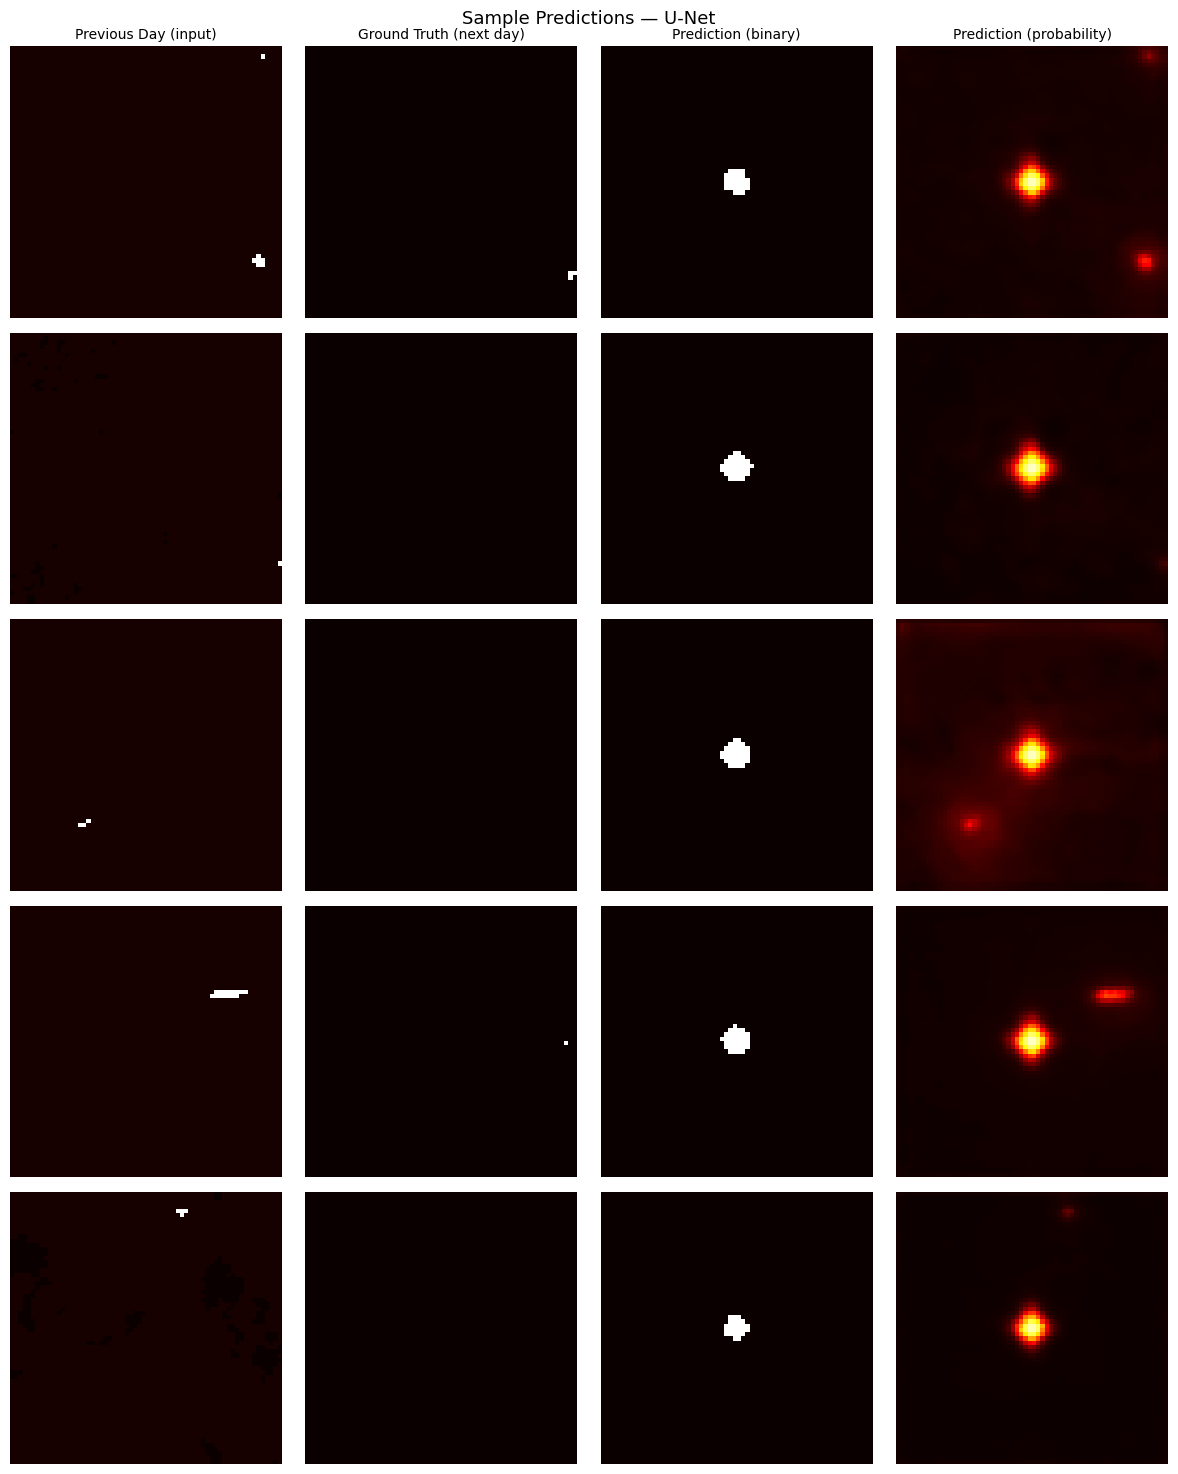

In [39]:
# ============================================================
# CELL 37 — SHARED EVALUATOR: U-NET PREDICTION VISUALIZATION
# ============================================================

plot_prediction_grid(
    model=model,
    test_loader=test_loader,
    device=device,
    model_name="U-Net",
    n_samples=5,
    threshold=DEFAULT_THRESHOLD
)

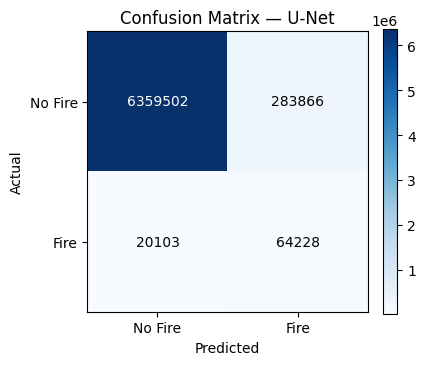

In [40]:
# ============================================================
# CELL 38 — SHARED EVALUATOR: U-NET CONFUSION MATRIX
# ============================================================

cm = results["metrics"]["confusion_matrix"]

plot_confusion_matrix(
    cm=cm,
    model_name="U-Net"
)

plt.show()

In [41]:
# ============================================================
# CELL 39 — CHECK EXISTING U-NET TRAINING HISTORY
# ============================================================

print("Variables containing 'history' or 'loss':")

for name in sorted(globals()):
    if "history" in name.lower() or "loss" in name.lower():
        try:
            value = globals()[name]
            print(f"{name}: {type(value)}")
        except:
            pass

Variables containing 'history' or 'loss':


In [42]:
# ============================================================
# CELL 40 — INSPECT SAVED U-NET CHECKPOINT
# ============================================================

checkpoint = torch.load(
    CHECKPOINT_FILE,
    map_location="cpu"
)

print("Checkpoint contents:")
print()

for key, value in checkpoint.items():
    if torch.is_tensor(value):
        print(f"{key}: Tensor {tuple(value.shape)}")
    else:
        print(f"{key}: {value}")

Streaming output truncated to the last 5000 lines.
        2.4242e-11, 2.9174e-11, 7.6652e-11, 3.1471e-11, 5.2631e-11, 2.0661e-11,
        2.2601e-11, 3.4519e-11, 2.1826e-11, 1.4294e-11, 3.6760e-11, 3.2155e-11,
        3.9638e-11, 2.0294e-11, 1.1321e-11, 1.1247e-11, 6.7835e-11, 1.3465e-11,
        2.1376e-11, 2.5112e-11, 2.0163e-11, 8.3984e-12, 3.2807e-11, 1.3589e-11,
        3.1460e-11, 4.5813e-11, 2.2419e-11, 2.1897e-11, 5.2106e-11, 2.0369e-11,
        2.6568e-11, 6.9023e-11, 2.2217e-11, 4.5210e-11, 1.6864e-11, 2.6251e-11,
        1.7815e-11, 2.0202e-11, 3.2828e-11, 3.5865e-11, 1.8784e-11, 3.5504e-11,
        1.4230e-11, 2.6244e-11, 3.0632e-11, 9.1695e-11, 1.6492e-11, 2.9874e-11,
        3.1157e-11, 6.2198e-11, 2.8388e-11, 3.0416e-11, 1.2771e-11, 4.9820e-11,
        3.4343e-11, 2.2282e-11, 2.5598e-11, 1.9701e-11, 1.4862e-11, 3.9700e-11,
        2.2713e-11, 4.7596e-11, 2.1430e-11, 2.0926e-11, 3.2614e-11, 2.1887e-11,
        2.6633e-11, 2.0908e-11, 7.0484e-11, 6.6375e-11, 1.8260e-11, 4

In [43]:
# ============================================================
# CELL 41 — SAVE U-NET EVALUATION RESULTS
# ============================================================

UNET_RESULTS_FILE = RESULTS_DIR / "unet_metrics.json"

save_results(
    results,
    str(UNET_RESULTS_FILE)
)

print("\nSaved U-Net evaluation results to:")
print(UNET_RESULTS_FILE)

Saved results to /content/drive/MyDrive/wildfire_project/results/unet_metrics.json

Saved U-Net evaluation results to:
/content/drive/MyDrive/wildfire_project/results/unet_metrics.json


In [44]:
def calculate_masked_loss(model, inputs, targets, masks):
    """
    Calculate BCEWithLogitsLoss while ignoring uncertain pixels.

    Target values:
        0  = no fire
        1  = fire
       -1  = uncertain

    Mask values:
        1 = valid pixel
        0 = ignore pixel
    """

    # Move data to the same device as the model
    inputs = inputs.to(device)
    targets = targets.to(device)
    masks = masks.to(device)

    # Replace -1 uncertain targets with 0.
    # These pixels will still be ignored by the mask.
    targets_clean = torch.where(
        masks > 0,
        targets,
        torch.zeros_like(targets)
    )

    # Forward pass
    logits = model(inputs)

    # Calculate pixel-level loss
    loss_map = criterion(logits, targets_clean)

    # Keep only valid pixels
    loss = (
        loss_map * masks
    ).sum() / masks.sum().clamp_min(1.0)

    return loss, logits


# ============================================================
# TRAINING FUNCTION
# ============================================================

def train_one_epoch(model, loader, optimizer):
    """
    Train the model for one complete epoch.
    """

    model.train()

    total_loss = 0.0
    total_valid_pixels = 0

    for inputs, targets, masks in loader:

        # Move data to GPU
        inputs = inputs.to(device)
        targets = targets.to(device)
        masks = masks.to(device)

        # Replace uncertain target values
        targets_clean = torch.where(
            masks > 0,
            targets,
            torch.zeros_like(targets)
        )

        # Clear old gradients
        optimizer.zero_grad()

        # Forward pass
        logits = model(inputs)

        # Pixel-level BCE loss
        loss_map = criterion(logits, targets_clean)

        # Ignore uncertain pixels
        loss = (
            loss_map * masks
        ).sum() / masks.sum().clamp_min(1.0)

        # Backpropagation
        loss.backward()

        # Update model parameters
        optimizer.step()

        # Keep track of loss
        valid_pixels = masks.sum().item()

        total_loss += loss.item() * valid_pixels
        total_valid_pixels += valid_pixels

    # Average loss over all valid pixels
    epoch_loss = total_loss / max(total_valid_pixels, 1.0)

    return epoch_loss


# ============================================================
# VALIDATION FUNCTION
# ============================================================

def validate_one_epoch(model, loader):
    """
    Evaluate the model on the validation set.

    IMPORTANT:
    No model weights are updated here.
    """

    model.eval()

    total_loss = 0.0
    total_valid_pixels = 0

    # No gradients are needed during validation
    with torch.no_grad():

        for inputs, targets, masks in loader:

            # Move data to GPU
            inputs = inputs.to(device)
            targets = targets.to(device)
            masks = masks.to(device)

            # Replace uncertain target values
            targets_clean = torch.where(
                masks > 0,
                targets,
                torch.zeros_like(targets)
            )

            # Forward pass
            logits = model(inputs)

            # Pixel-level loss
            loss_map = criterion(logits, targets_clean)

            # Ignore uncertain pixels
            loss = (
                loss_map * masks
            ).sum() / masks.sum().clamp_min(1.0)

            # Track loss
            valid_pixels = masks.sum().item()

            total_loss += loss.item() * valid_pixels
            total_valid_pixels += valid_pixels

    # Average validation loss
    epoch_loss = total_loss / max(total_valid_pixels, 1.0)

    return epoch_loss


print("Training and validation functions defined successfully.")

Training and validation functions defined successfully.


In [47]:
# ============================================================
# U-NET TRAINING — ALREADY COMPLETED
# ============================================================
#
# The U-Net was trained for 20 epochs during the original
# training run.
#
# The best trained model was saved as:
# models/unet_best.pth
#
# This cell is kept for documentation only.
# DO NOT RUN THE TRAINING LOOP AGAIN.
# ============================================================

from pathlib import Path

BEST_MODEL_PATH = Path(
    "/content/drive/MyDrive/wildfire_project/models/unet_best.pth"
)

print("U-Net training was already completed.")
print("Existing checkpoint:")
print(BEST_MODEL_PATH)
print("Checkpoint exists:", BEST_MODEL_PATH.exists())

U-Net training was already completed.
Existing checkpoint:
/content/drive/MyDrive/wildfire_project/models/unet_best.pth
Checkpoint exists: True


In [48]:
# CELL 13: LOAD THE BEST MODEL

import torch

checkpoint = torch.load(
    BEST_MODEL_PATH,
    map_location=device,
    weights_only=False
)

# Restore the best model weights
model.load_state_dict(checkpoint["model_state_dict"])

# Save the best epoch number
best_epoch = checkpoint["epoch"]

print("Best model loaded successfully!")
print("Best epoch:", best_epoch)
print("Best validation loss:", checkpoint["val_loss"])
print("Model device:", next(model.parameters()).device)

Best model loaded successfully!
Best epoch: 4
Best validation loss: 0.3473974070150099
Model device: cpu


In [49]:
loss_plot_path = RESULTS_DIR / "unet_training_validation_loss.png"

print("Exists:", loss_plot_path.exists())
print("Path:", loss_plot_path)

Exists: True
Path: /content/drive/MyDrive/wildfire_project/results/unet_training_validation_loss.png


Original training/validation loss curve:
/content/drive/MyDrive/wildfire_project/results/unet_training_validation_loss.png
Exists: True


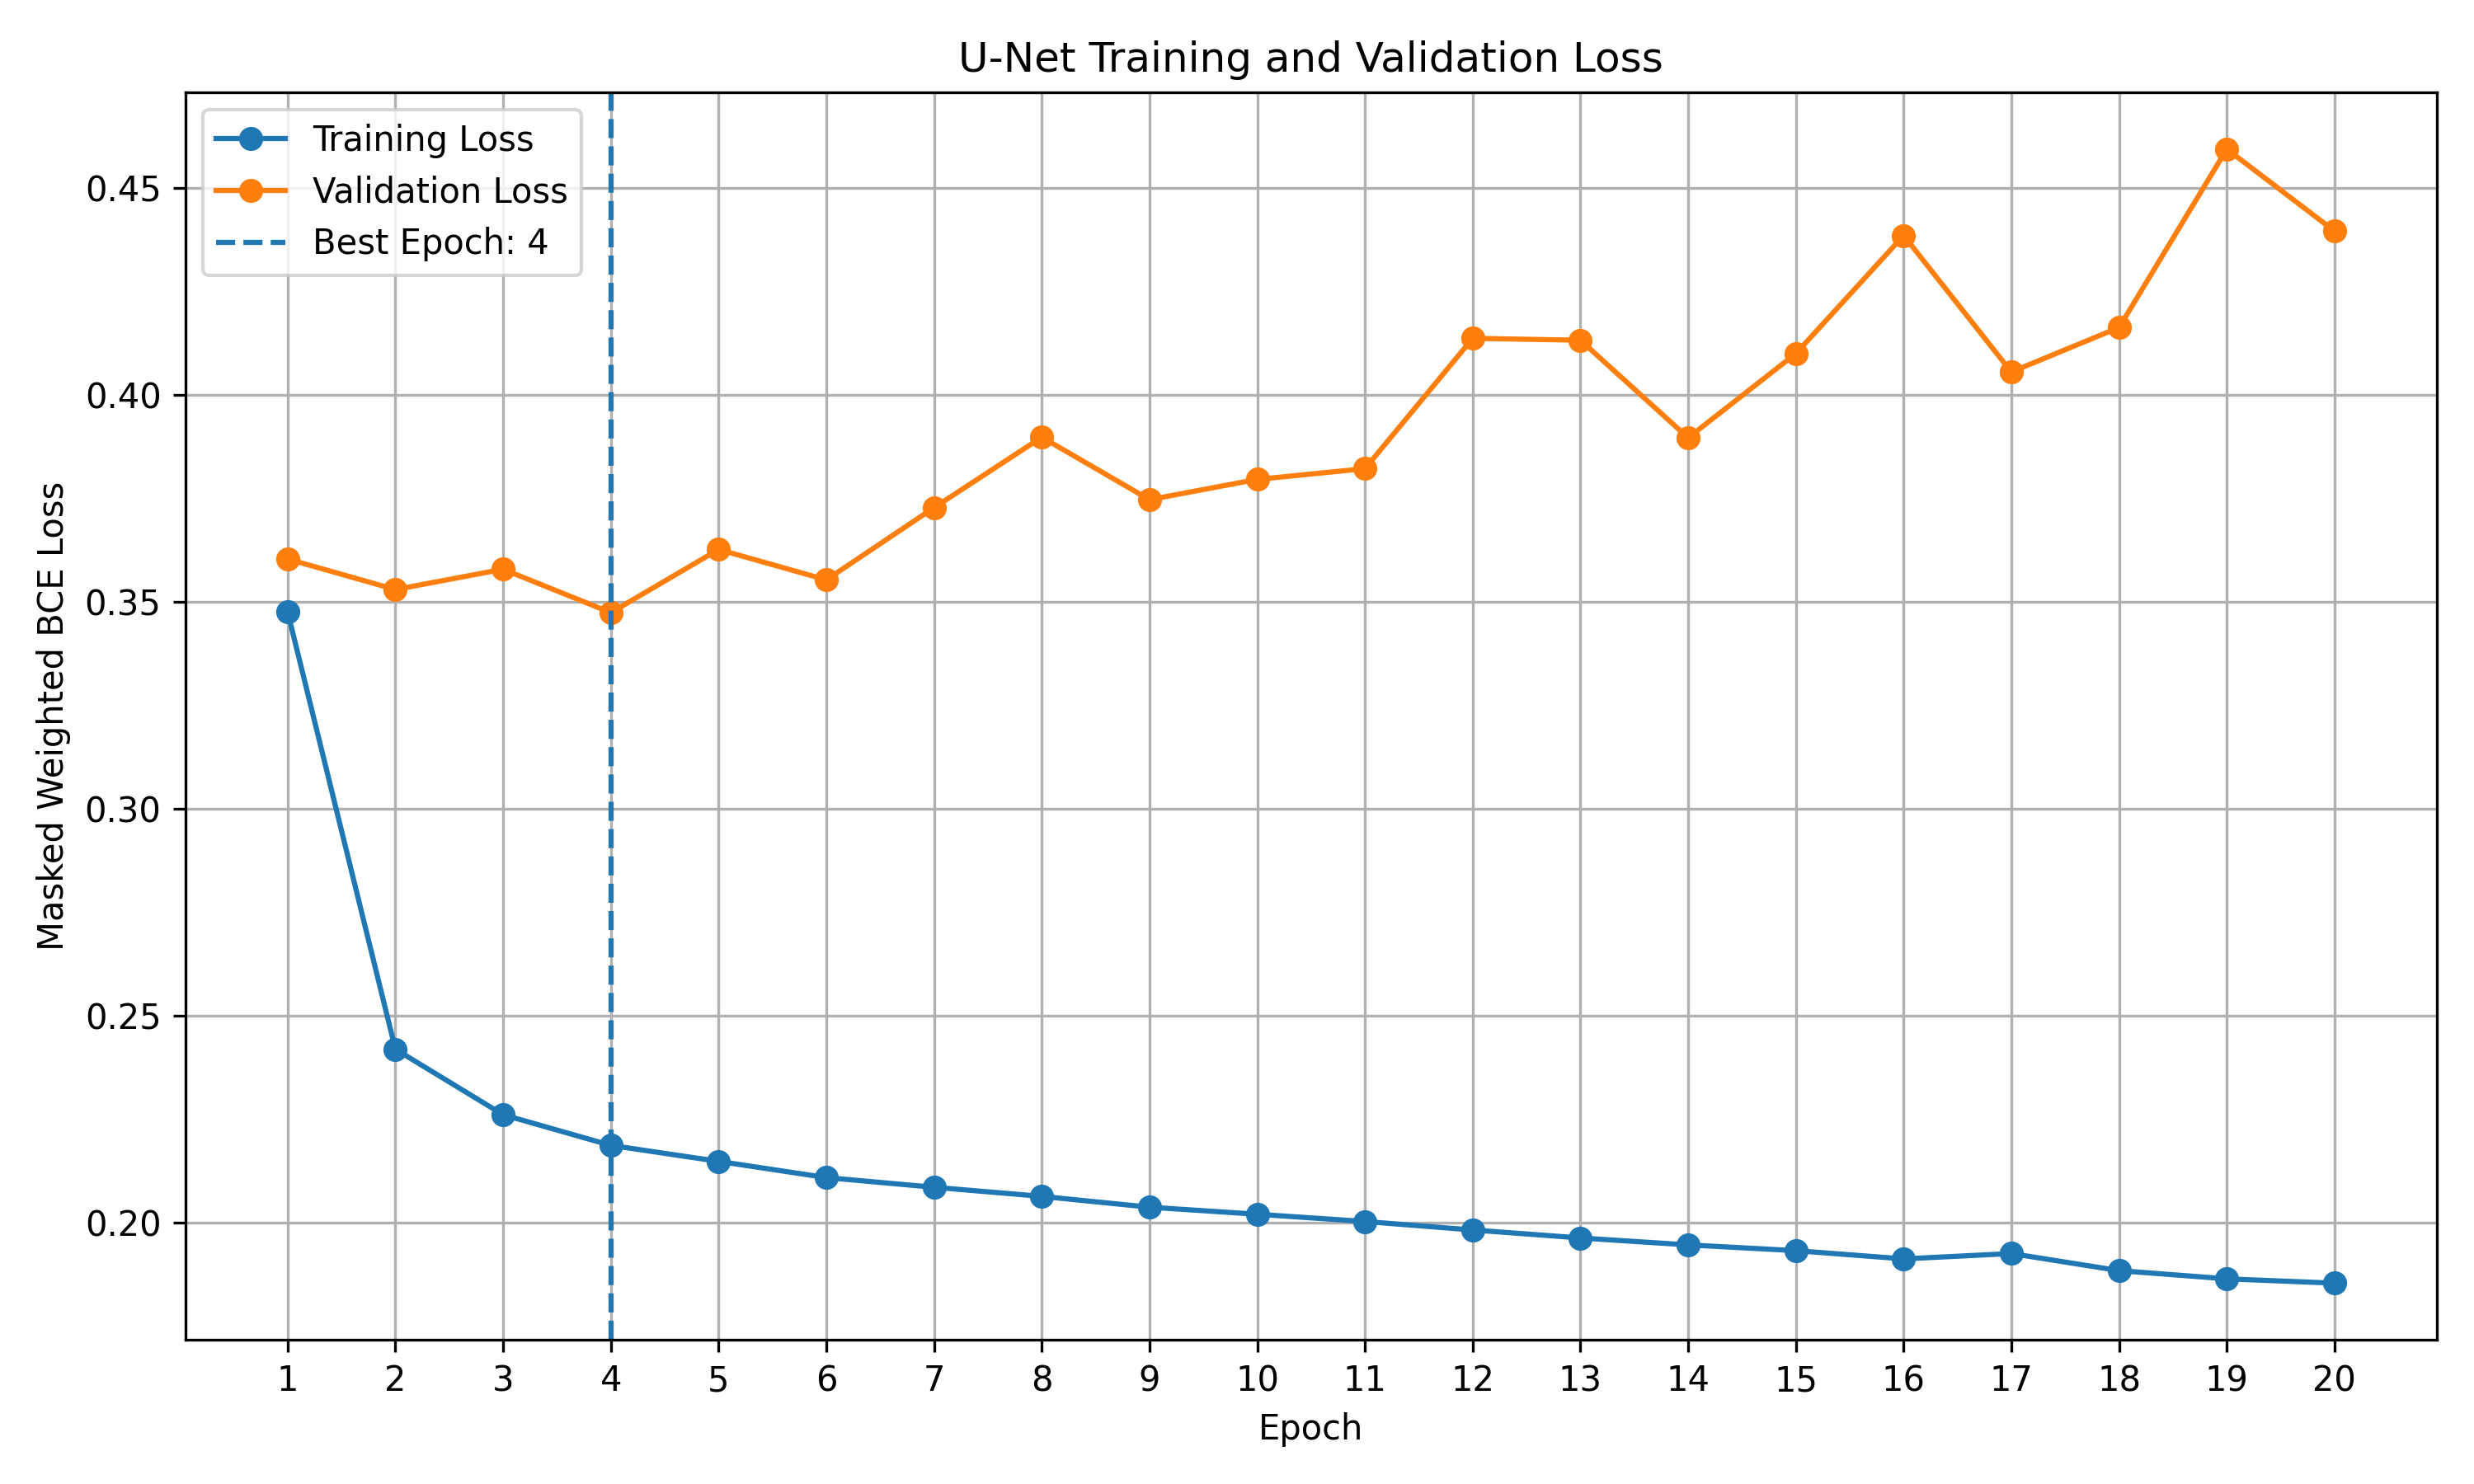

In [51]:
# ============================================================
# U-NET TRAINING / VALIDATION LOSS CURVE
# ============================================================
#
# The original training curve was already generated during
# the completed training run and saved to the results folder.
#
# The epoch-by-epoch train_losses and val_losses are not
# stored in the checkpoint, so we do not recreate the graph.
# ============================================================

from pathlib import Path
from IPython.display import Image, display

loss_plot_path = Path(
    "/content/drive/MyDrive/wildfire_project/results/unet_training_validation_loss.png"
)

print("Original training/validation loss curve:")
print(loss_plot_path)
print("Exists:", loss_plot_path.exists())

if loss_plot_path.exists():
    display(Image(filename=str(loss_plot_path)))
else:
    print("Training curve file was not found.")

In [53]:
# ============================================================
# U-NET FINAL TEST RESULTS
# ============================================================

import time

evaluation_start_time = time.time()

results = evaluate_model(
    model=model,
    test_loader=test_loader,
    device=device,
    model_name="U-Net",
    training_time_sec=0.0,
    num_params=sum(
        p.numel()
        for p in model.parameters()
    ),
)

evaluation_time = time.time() - evaluation_start_time

print("=" * 60)
print("U-NET FINAL TEST RESULTS")
print("=" * 60)

print(f"Model: {results['model_name']}")
print(f"Threshold: {results['threshold']}")

print("\nMetrics:")
for key, value in results["metrics"].items():
    if key != "confusion_matrix":
        print(f"{key}: {value}")

print("\nConfusion Matrix:")
print(results["metrics"]["confusion_matrix"])

print(f"\nNumber of parameters: {results['num_params']}")
print(f"Evaluation time: {evaluation_time:.2f} seconds")

U-NET FINAL TEST RESULTS
Model: U-Net
Threshold: 0.5

Metrics:
accuracy: 0.9548182818523837
precision: 0.18451337857015634
recall: 0.7616179103769669
f1: 0.29705960571197315
iou: 0.17443922682694318
roc_auc: 0.9428962791217745

Confusion Matrix:
[[6359502, 283866], [20103, 64228]]

Number of parameters: 31048705
Evaluation time: 148.16 seconds


In [55]:
# ============================================================
# SAVE U-NET FINAL RESULTS
# ============================================================

UNET_RESULTS_FILE = RESULTS_DIR / "unet_metrics.json"

save_results(
    results,
    str(UNET_RESULTS_FILE)
)

print("U-Net results saved to:")
print(UNET_RESULTS_FILE)

Saved results to /content/drive/MyDrive/wildfire_project/results/unet_metrics.json
U-Net results saved to:
/content/drive/MyDrive/wildfire_project/results/unet_metrics.json
